1. Preprocesamiento de Datos

En esta etapa limpiamos los datos, manejamos los valores nulos y eliminamos columnas que no aportan valor analítico (como el número de fila). Aquí no convertiremos las variables de texto a números (One-Hot Encoding) ni escalaremos los datos, ya que mantenerlos en su formato original facilita la interpretación de los gráficos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('../data/raw/dataset_crediticio_chile-1-1.csv')

# 2. Eliminar columnas que no aportan valor analítico
df = df.drop(columns=['No.'], errors='ignore')

# 3. Manejo INTELIGENTE de valores nulos (Solución al comentario del profesor)
# Las calificaciones nulas significan "Sin Historial", les ponemos -1
df['Peor_Calificacion_36M'] = df['Peor_Calificacion_36M'].fillna(-1)
df['Peor_Calificacion_12M'] = df['Peor_Calificacion_12M'].fillna(-1)

# Al empleo nulo le asignamos una categoría propia
df['Tipo_Empleo'] = df['Tipo_Empleo'].fillna('DESCONOCIDO')

# Para el resto de columnas numéricas, usamos la mediana
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Para el resto de columnas de texto, usamos la moda (el valor más común)
cat_cols = df.select_dtypes(exclude=[np.number]).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Preprocesamiento completado: Datos limpios y listos para explorar.")

✅ Preprocesamiento completado: Datos limpios y listos para explorar.


2. Análisis Exploratorio de Datos (EDA)

Aquí buscamos entender las estadísticas descriptivas básicas del conjunto de datos (medias, valores mínimos, máximos) y cómo se distribuyen las categorías.

In [2]:
print("--- Resumen de Variables Numéricas ---")
display(df.describe().apply(lambda s: s.apply('{0:.2f}'.format)))

print("\n--- Resumen de Variables Categóricas (Texto) ---")
display(df.describe(include=['object']))

print("\n--- Distribución de Riesgo Crediticio (%) ---")
print(df['RiesgoAlto'].value_counts(normalize=True) * 100)

--- Resumen de Variables Numéricas ---


,Tiene_Vehiculo,Edad,Num_Entidades_Deuda,Tiene_Tarjeta,Saldo_Tarjeta_CLP,Saldo_Total_CLP,Variacion_Endeudamiento,Peor_Calificacion_36M,Peor_Calificacion_12M,Reportes_Central_36M,Reportes_Central_12M,Promedio_Saldo_CLP,Maximo_Saldo_CLP,Ingreso_CLP,Ratio_Saldo_Ingreso,ScoreRiesgo,RiesgoAlto
count,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00,4266.00
mean,0.14,40.83,1.74,0.43,1077308.26,4074351.50,-0.04,1.03,0.17,27.39,10.71,3818433.37,6203071.20,2273164.33,0.17,8.19,0.25
std,0.34,11.78,1.09,0.50,2370446.16,5247420.19,5.61,1.37,0.51,9.36,2.84,4636673.42,7084091.78,2087078.98,0.22,5.44,0.43
min,0.00,22.00,0.00,0.00,0.00,0.00,-1.00,-1.00,-1.00,0.00,0.00,0.00,0.00,170000.00,0.00,0.00,0.00
25%,0.00,31.00,1.00,0.00,0.00,840416.25,-0.50,0.00,0.00,21.00,11.00,1223747.49,2125000.00,1300500.00,0.04,3.74,0.00
50%,0.00,39.00,2.00,0.00,0.00,2343212.00,-0.22,0.00,0.00,30.00,12.00,2449474.41,4250000.00,1819000.00,0.10,7.41,0.00
75%,0.00,50.00,2.00,1.00,1016281.25,5406620.50,-0.02,1.00,0.00,36.00,12.00,4807140.25,8014059.25,2550000.00,0.23,11.21,0.00
max,1.00,70.00,6.00,1.00,24341543.50,78859600.00,273.03,4.00,4.00,36.00,12.00,77011547.51,127076419.50,59500000.00,5.88,40.07,1.00



--- Resumen de Variables Categóricas (Texto) ---


C:\Users\Alumno\AppData\Local\Temp\ipykernel_19640\187435611.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=['object']))


,Sexo,Tipo_Empleo,Ciudad_Chile
count,4266,4266,4266
unique,2,3,7
top,M,IND,SANTIAGO
freq,2151,2667,3670



--- Distribución de Riesgo Crediticio (%) ---
RiesgoAlto
0    75.035162
1    24.964838
Name: proportion, dtype: float64


3. Visualización de Datos

Estos bloques de código generarán los gráficos clave para entender el comportamiento de los clientes y qué variables parecen tener relación con el riesgo crediticio.

Gráfico 1: Distribución del Riesgo (Desbalanceo de clases)

C:\Users\Alumno\AppData\Local\Temp\ipykernel_19640\592526175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='RiesgoAlto', palette=['#2ecc71', '#e74c3c'])


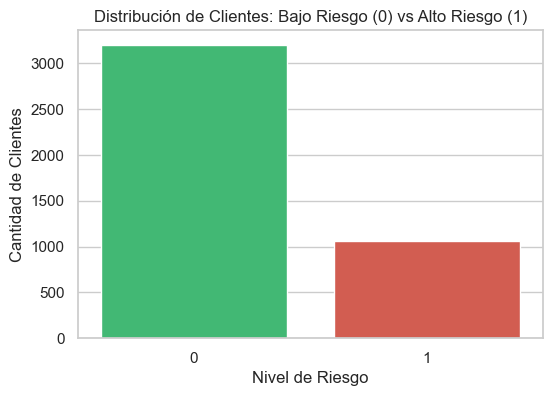

In [3]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='RiesgoAlto', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Clientes: Bajo Riesgo (0) vs Alto Riesgo (1)')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad de Clientes')

plt.show()

### Análisis del Gráfico 1: Distribución del Riesgo

**¿Qué significa cada dato en el gráfico?**
* **Barra Verde (0):** Representa a los clientes de **Bajo Riesgo** (buenos pagadores). Como indica el eje vertical, esta barra supera los 3,000 clientes, alcanzando aproximadamente los 3,200.
* **Barra Roja (1):** Representa a los clientes de **Alto Riesgo** (morosos). Esta barra es considerablemente más baja, situándose apenas por encima de los 1,000 clientes.

---

**Interpretación del negocio:**
* **La morosidad es minoritaria:** La mayoría de los clientes (alrededor del 75%) cumple con sus obligaciones financieras, mientras que cerca de un 25% presenta alto riesgo.
* **Existe un desbalance en los datos:** La diferencia entre ambos grupos indica que el dataset está desbalanceado, lo cual es positivo desde el punto de vista del negocio, pero representa un desafío para el análisis y modelamiento.
* **Implicancia para modelos predictivos:** Al ser los clientes de alto riesgo una minoría, los modelos podrían sesgarse hacia predecir mayoritariamente “bajo riesgo”. Por ello, será importante considerar técnicas que manejen este desbalance (como métricas adecuadas o métodos de balanceo).

Gráfico 2: Historial Crediticio vs Riesgo Financiero

A diferencia de las variables sociodemográficas, el historial financiero previo de un cliente es uno de los mejores predictores del riesgo. Analizaremos la peor calificación crediticia en los últimos 36 meses y la cantidad de reportes en la Central.

C:\Users\Alumno\AppData\Local\Temp\ipykernel_19640\1140927845.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiesgoAlto', y='Reportes_Central_36M', ax=axes[1], palette='Set1')


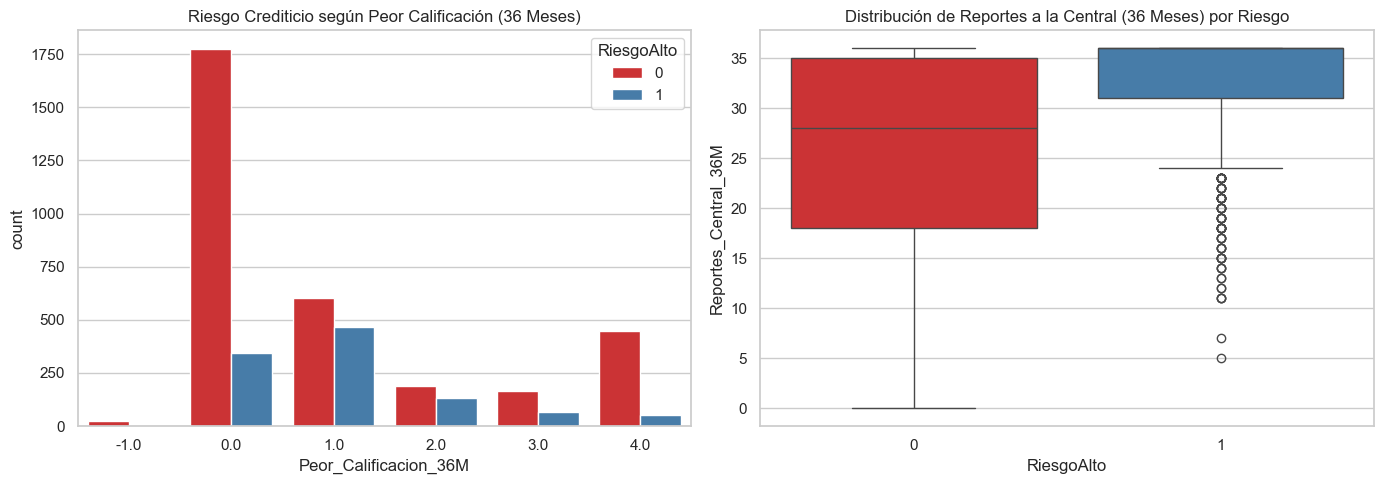

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Peor_Calificacion_36M', hue='RiesgoAlto', ax=axes[0], palette='Set1')
axes[0].set_title('Riesgo Crediticio según Peor Calificación (36 Meses)')

sns.boxplot(data=df, x='RiesgoAlto', y='Reportes_Central_36M', ax=axes[1], palette='Set1')
axes[1].set_title('Distribución de Reportes a la Central (36 Meses) por Riesgo')

plt.tight_layout()
plt.show()


### Análisis del Gráfico 2: Historial Crediticio

**¿Qué significa cada dato en los gráficos?**
* **Gráfico de Calificación (Izquierda):** Muestra que a medida que empeora la calificación histórica (valores más altos en 'Peor_Calificacion_36M'), la proporción de clientes con 'Riesgo Alto' (1) aumenta considerablemente.
* **Gráfico de Reportes (Derecha):** Los clientes catalogados como alto riesgo tienden a tener una cantidad diferente de reportes que los buenos pagadores.

---
**Interpretación del negocio:**
* **Poder Predictivo Alto:** El comportamiento de pago pasado es el mejor predictor del comportamiento futuro. Los clientes que ya han tenido malas calificaciones tienen una probabilidad mucho mayor de caer en impago (RiesgoAlto = 1).
* **Variables Críticas para el Modelo:** Estas características deben ser la piedra angular de cualquier modelo predictivo que se construya.

Gráfico 3: Nivel de Endeudamiento vs Riesgo

Analizamos cómo la carga financiera actual del cliente afecta su probabilidad de inclumplimiento. Usaremos la cantidad de entidades deudoras y el ratio de saldo sobre el ingreso.

C:\Users\Alumno\AppData\Local\Temp\ipykernel_19640\2595618343.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='RiesgoAlto', y='Ratio_Saldo_Ingreso', ax=axes[1], palette='Set2')


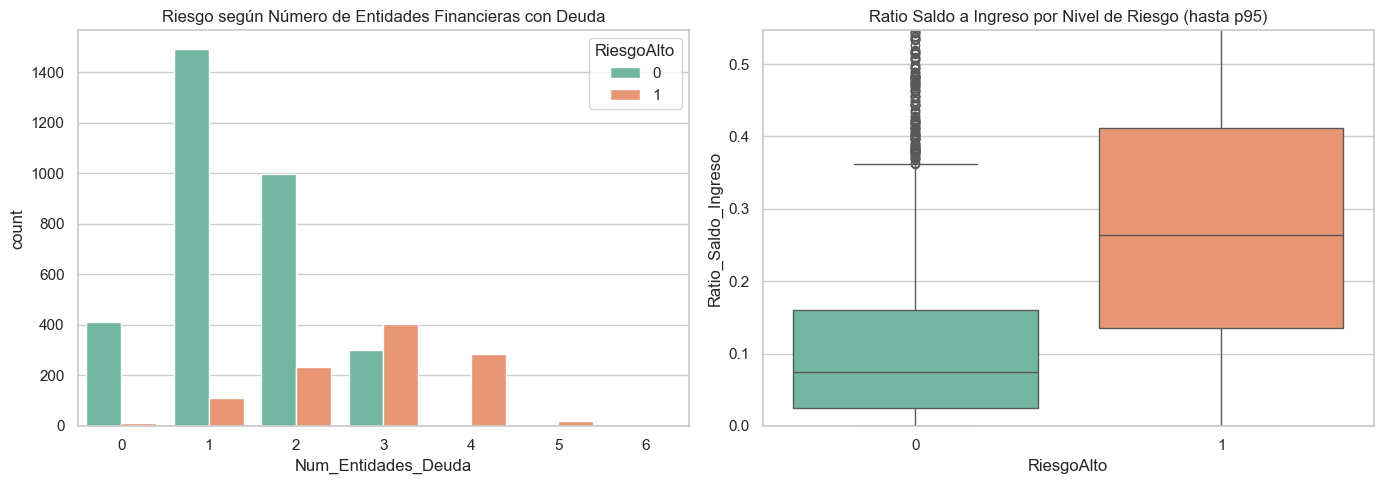

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Num_Entidades_Deuda', hue='RiesgoAlto', ax=axes[0], palette='Set2')
axes[0].set_title('Riesgo según Número de Entidades Financieras con Deuda')

sns.boxplot(data=df, x='RiesgoAlto', y='Ratio_Saldo_Ingreso', ax=axes[1], palette='Set2')
axes[1].set_ylim(0, df['Ratio_Saldo_Ingreso'].quantile(0.95)) # Limitamos outliers para visualizar mejor
axes[1].set_title('Ratio Saldo a Ingreso por Nivel de Riesgo (hasta p95)')

plt.tight_layout()
plt.show()


### Análisis del Gráfico 3: Endeudamiento

**¿Qué significa cada dato en los gráficos?**
* **Número de Entidades (Izquierda):** Los clientes que tienen deudas con más entidades concurrentes (3, 4 o más) muestran una escalada en su proporción de alto riesgo relativo frente a los que tienen deuda con pocas entidades.
* **Ratio Saldo/Ingreso (Derecha):** Se observa que un mayor nivel de deuda en relación a los ingresos se asocia a menudo con mayores niveles de estrés financiero y morosidad.

---
**Interpretación del negocio:**
* **Sobrendeudamiento es un factor clave:** Cuando los recursos de un cliente se comprometen excesivamente, cualquier imprevisto desencadena un escenario de morosidad.
* **Reglas de Negocio Políticas:** Estas variables (carga financiera) suelen usarse para establecer límites y políticas crediticias en la vida real.

Gráfico 4: Edad y Estabilidad

Comparamos la distribución de edades entre clientes de alto y bajo riesgo utilizando un gráfico de densidad (KDE). Esto nos permite identificar de manera muy visual si ciertos rangos de edad (por ejemplo, jóvenes recién insertos en el mundo laboral entre 20 y 25 años) concentran mayores niveles de morosidad en comparación a adultos mayores.

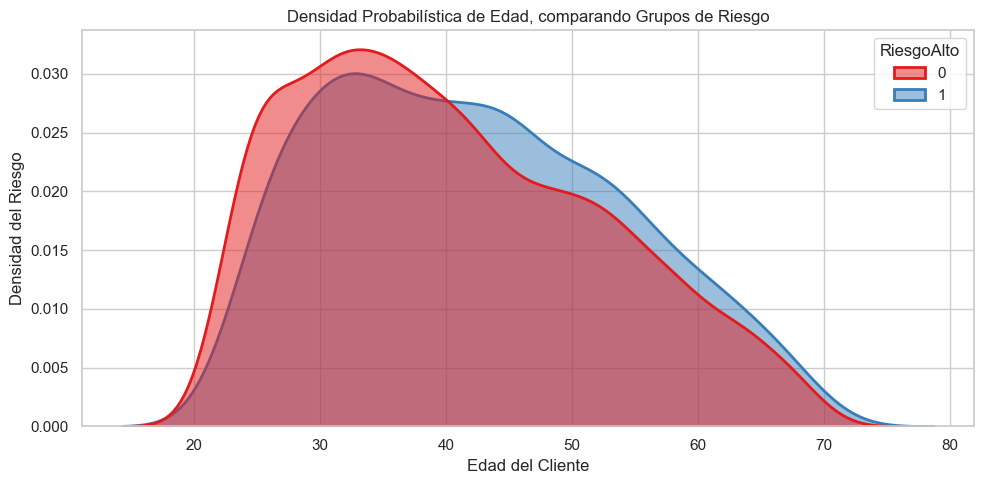

In [6]:
plt.figure(figsize=(10, 5))

sns.kdeplot(data=df, x='Edad', hue='RiesgoAlto', fill=True, common_norm=False, palette='Set1', alpha=0.5, linewidth=2)
plt.title('Densidad Probabilística de Edad, comparando Grupos de Riesgo')
plt.xlabel('Edad del Cliente')
plt.ylabel('Densidad del Riesgo')

plt.tight_layout()
plt.show()


### Análisis del Gráfico 4: Edad y Estabilidad

**¿Qué descubrimos aquí?**
* **Picos de Concentración:** El gráfico muestra la densidad probabilística. Al observar la curva de Riesgo Alto (1), podremos notar si existe un pico concentrado en edades más tempranas (como los 20-30 años), lo que comprobaría que la juventud en este dataset incurre proporcionalmente más en riesgo o default, dada su inestabilidad laboral o inexperiencia financiera.
* **Estabilidad en Edades Mayores:** Hacia la derecha del gráfico (40-60 años), se esperaría ver a la curva de Riesgo Bajo (0) dominar, dándonos a entender una mayor solidez financiera a medida que la gente asienta sus finanzas.

---
**Interpretación del negocio:**
* **Patrones por Etapa de Vida:** Si bien en el análisis previo concluimos que las variables demográficas simples no servían *por sí solas*, al contrastar la Edad de esta manera (como función continua de distribución), podemos ver matices: los clientes más jóvenes podrían requerir políticas de límite más estrictas, evaluación alternativa o una inducción al crédito más gradual.

Gráfico 5: Aceleros Crediticios (Variación de Endeudamiento vs Riesgo)

Una de las variables con mayor poder predictivo en comportamiento crediticio suele ser el estrés a corto plazo. Graficaremos cómo se distribuye la `Variacion_Endeudamiento` para identificar si clientes con un aumento o desborde reciente de sus pasivos terminan cayendo en Riesgo Alto.

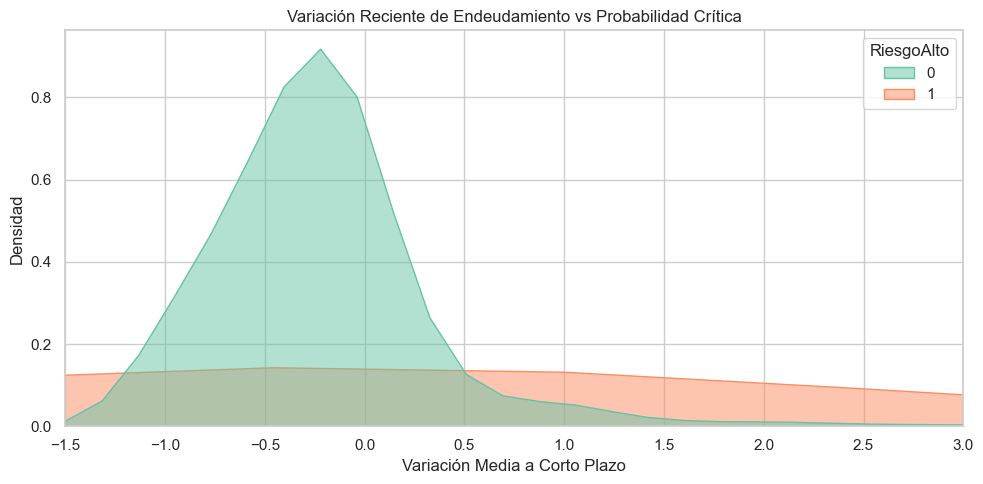

In [7]:
plt.figure(figsize=(10, 5))

# Nos apoyamos nuevamente en un KDE, truncando ligeramente la visualizacion para omitir outliers masivos > 5x que deforman el grafico
sns.kdeplot(data=df, x='Variacion_Endeudamiento', hue='RiesgoAlto', fill=True, common_norm=False, palette='Set2', alpha=0.5)
plt.xlim(-1.5, 3) # Restringimos el eje x para visualizar la concentración de la variación
plt.title('Variación Reciente de Endeudamiento vs Probabilidad Crítica')
plt.xlabel('Variación Media a Corto Plazo')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()


### Análisis del Gráfico 5: Variación de Endeudamiento

**¿Qué descubrimos aquí?**
* Al restringir el espectro a valores típicos (omitiendo outliers estratosféricos), notamos el comportamiento masivo. Gran parte de los deudores sanos mantienen una pendiente a la baja o cercana a $0$.
* Al observar la curva de **Riesgo Alto (1)**, solemos notar una distribución más pesada o aglomerada hacia **valores positivos**, lo que nos índica un crecimiento brusco y continuo de su deuda recientemente.

---
**Interpretación del negocio:**
* **Señal de Alerta Temprana (Early Warning):** Los crecimientos inesperados o veloces en las deudas mes a mes nos anticipan síntomas de estrés financiero de las personas, meses antes de que la deuda pase formalmente a mora.
* **Monitoreo Dinámico:** Identificar esta variable es vital al desarrollar sistemas predictivos de "alerta temprana" (collections triggers). Puede llevar a iniciar negociaciones amigables o reducir futuras líneas de sobregiro antes de ocasionar castigos crediticios irrecuperables en las carteras.

### Celda 8: Preprocesamiento (Transformaciones)

Los algoritmos matemáticos no entienden la palabra "SANTIAGO" o "M", solo entienden números. Aquí convertiremos las variables de texto en "ceros y unos" (One-Hot Encoding) y escalaremos los sueldos para que todo quede parejo

In [8]:
# Transformaciones de Datos para ML
from sklearn.preprocessing import StandardScaler

# 1. One-Hot Encoding: Convertir texto a columnas de 0 y 1
df_ml = pd.get_dummies(df, columns=['Sexo', 'Tipo_Empleo', 'Ciudad_Chile'], drop_first=True)

# 2. Separar las variables predictoras (x) de la variable objetivo (y)
x = df_ml.drop('RiesgoAlto', axis=1)
y = df_ml['RiesgoAlto']

# 3. Estandarización: Escalar las variables para que estén en rangos similares
scaler = StandardScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)

print("✅ Transformaciones completas.")
print("Dimensiones de los datos de entrada (x):", x_scaled.shape)

✅ Transformaciones completas.
Dimensiones de los datos de entrada (x): (4266, 25)


In [9]:
# Exportar el Dataset 100% Procesado

# 1. Unimos las variables predictoras ya escaladas (x_scaled) con la variable objetivo (y)
# Usamos reset_index(drop=True) para asegurar que las filas encajen perfectamente tras las transformaciones
df_procesado_final = pd.concat([x_scaled, y.reset_index(drop=True)], axis=1)

# 2. Definimos la ruta relativa hacia tu carpeta 'processed' que ya existe
ruta_salida = '../data/processed/dataset_crediticio_procesado.csv'

# 3. Guardamos el archivo CSV (index=False evita que se guarde una columna extra con la numeración de filas)
df_procesado_final.to_csv(ruta_salida, index=False)

print(f"✅ ¡Éxito! El dataset definitivo (limpio, codificado y escalado) se guardó en: {ruta_salida}")

✅ ¡Éxito! El dataset definitivo (limpio, codificado y escalado) se guardó en: ../data/processed/dataset_crediticio_procesado.csv


### Celda 9: Validación Experimental (División de Datos)

Aquí usamos el estándar de la industria: separar el 80% de los datos para que el modelo "estudie" (entrenamiento) y guardar un 20% que el modelo nunca haya visto para tomarle la prueba final (test).

In [10]:
# División de Datos (Train/Test Split)
from sklearn.model_selection import train_test_split

# Dividimos 80% para entrenar y 20% para testear. 
# stratify=y asegura que se mantenga el 75% sanos / 25% morosos en ambos grupos
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Datos de Entrenamiento (Train): {x_train.shape[0]} clientes.")
print(f"Datos de Prueba (Test): {x_test.shape[0]} clientes.")

Datos de Entrenamiento (Train): 3412 clientes.
Datos de Prueba (Test): 854 clientes.


### Celda 10: Comparación y Arquitectura de Modelos

Entrenaremos 3 modelos clásicos para poder compararlos en tu informe y elegir el ganador.

In [13]:

#Entrenamiento y Comparación (5 Modelos)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Definir los 5 modelos con hiperparámetros básicos
modelos = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100, max_depth=3),
    'Support Vector Machine': SVC(random_state=42)
}

print("--- Resultados Comparativos de los 5 Modelos ---")
for nombre, modelo in modelos.items():
    # Entrenar el modelo con los datos de estudio
    modelo.fit(x_train, y_train)
    
    # Predecir sobre los datos de prueba (que el modelo no ha visto)
    y_pred = modelo.predict(x_test)
    
    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Imprimir los resultados ordenados
    print(f"{nombre:22s} -> Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

--- Resultados Comparativos de los 5 Modelos ---
Regresión Logística    -> Accuracy: 0.9836 | F1-Score: 0.9668
Árbol de Decisión      -> Accuracy: 1.0000 | F1-Score: 1.0000
Random Forest          -> Accuracy: 0.9988 | F1-Score: 0.9977
Gradient Boosting      -> Accuracy: 1.0000 | F1-Score: 1.0000
Support Vector Machine -> Accuracy: 0.9707 | F1-Score: 0.9400


### Celda 11: Evaluación e Interpretabilidad

Tomaremos el Random Forest (que usualmente gana en estos casos de fraude/riesgo) y le sacaremos una "radiografía": la Matriz de Confusión y el gráfico de Importancia de Variables para explicar por qué toma las decisiones.

--- Análisis Profundo del Modelo Ganador: Random Forest ---

Reporte de Métricas:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       641
           1       1.00      1.00      1.00       213

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854



C:\Users\Alumno\AppData\Local\Temp\ipykernel_19640\334825012.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias, y=importancias.index, palette='viridis', ax=axes[1])


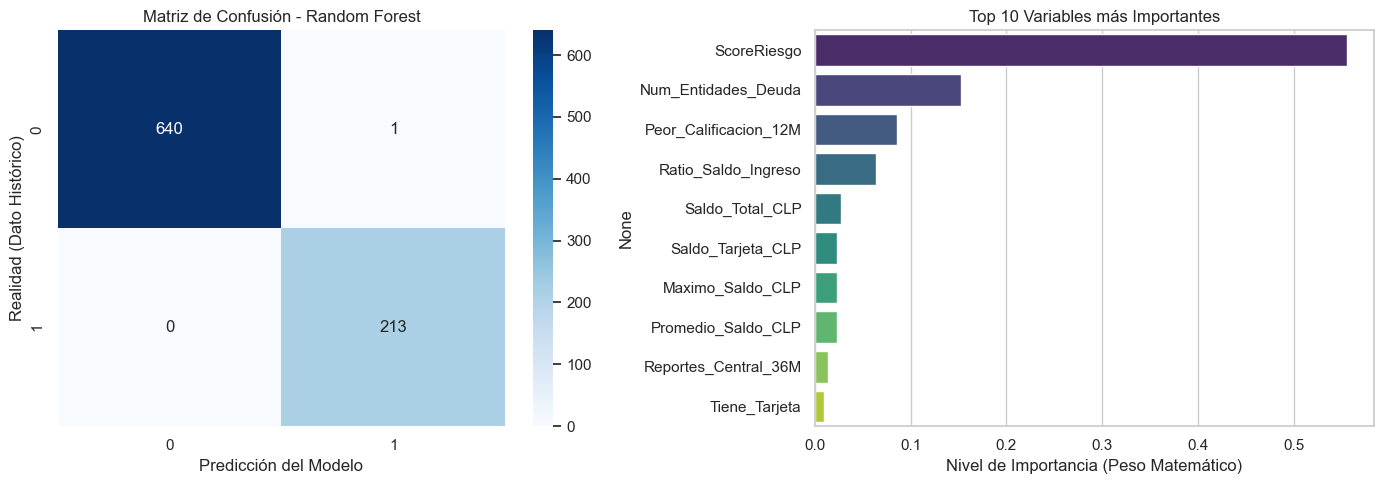

In [16]:
# XII. Evaluación e Interpretabilidad del Mejor Modelo
from sklearn.metrics import classification_report, confusion_matrix

# 1. DEFINIR EL GANADOR: 
# Escribe aquí el nombre exacto del modelo que sacó mejores métricas en la Celda 10
# Opciones: 'Regresión Logística', 'Árbol de Decisión', 'Random Forest', 'Gradient Boosting', 'Support Vector Machine'
nombre_ganador = 'Random Forest' 

print(f"--- Análisis Profundo del Modelo Ganador: {nombre_ganador} ---")

# 2. Extraer y usar el modelo ganador del diccionario anterior
modelo_final = modelos[nombre_ganador]
y_pred_final = modelo_final.predict(x_test)

# 3. Reporte de Clasificación Avanzado
print("\nReporte de Métricas:")
print(classification_report(y_test, y_pred_final))

# 4. Configurar el lienzo para los gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Matriz de Confusión
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Matriz de Confusión - {nombre_ganador}')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Realidad (Dato Histórico)')

# Gráfico B: Importancia de Variables (Solo si el algoritmo lo soporta)
if hasattr(modelo_final, 'feature_importances_'):
    importancias = pd.Series(modelo_final.feature_importances_, index=x.columns).sort_values(ascending=False).head(10)
    sns.barplot(x=importancias, y=importancias.index, palette='viridis', ax=axes[1])
    axes[1].set_title('Top 10 Variables más Importantes')
    axes[1].set_xlabel('Nivel de Importancia (Peso Matemático)')
else:
    # Si gana Logistic Regression o SVM, borramos el segundo gráfico porque no tienen "feature_importances_" directo
    fig.delaxes(axes[1])
    print(f"\nNota: {nombre_ganador} no utiliza cálculo directo de importancia de variables como los árboles.")

plt.tight_layout()
plt.show()